In [ ]:
# Hybrid feature engineering with entropy-Hjorth EEG features and stacking ensemble learning for epileptic seizure detection.

In [2]:
import numpy as np
import pandas as pd
import antropy as ant
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import lightgbm as lgb

In [3]:
df = pd.read_csv(r"D:\Datasets\BEED_Data.csv")

X = df.drop("y", axis=1)
y = df["y"]

In [4]:
X["mean"] = X.mean(axis=1)
X["std"] = X.std(axis=1)
X["var"] = X.var(axis=1)
X["max"] = X.max(axis=1)
X["min"] = X.min(axis=1)
X["range"] = X["max"] - X["min"]

In [5]:
def hjorth(signal):

    signal = np.array(signal)

    d1 = np.diff(signal)
    d2 = np.diff(d1)

    var0 = np.var(signal)+1e-8
    var1 = np.var(d1)+1e-8
    var2 = np.var(d2)+1e-8

    activity = var0
    mobility = np.sqrt(var1/var0)
    complexity = np.sqrt(var2/var1)/mobility

    return activity,mobility,complexity


activity=[]
mobility=[]
complexity=[]

for row in X.values:

    a,m,c = hjorth(row)

    activity.append(a)
    mobility.append(m)
    complexity.append(c)

X["hjorth_activity"]=activity
X["hjorth_mobility"]=mobility
X["hjorth_complexity"]=complexity

In [6]:
entropy_feats=[]

for row in X.values:

    try:
        features=[
            ant.sample_entropy(row),
            ant.app_entropy(row),
            ant.perm_entropy(row,normalize=True),
            ant.spectral_entropy(row,sf=100,method="fft")
        ]
    except:
        features=[0,0,0,0]

    entropy_feats.append(features)

entropy_feats=np.array(entropy_feats)

entropy_feats=np.nan_to_num(entropy_feats)

In [7]:
X = np.concatenate([X.values, entropy_feats], axis=1)

y = y.values

In [8]:
print("Total number of features:", X.shape[1])

Total number of features: 29


In [9]:
print("Original features:", df.drop("y", axis=1).shape[1])
print("Entropy features:", entropy_feats.shape[1])
print("Total features:", X.shape[1])

Original features: 16
Entropy features: 4
Total features: 29


In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
selector = SelectKBest(mutual_info_classif,k=25)

X_train = selector.fit_transform(X_train,y_train)
X_test = selector.transform(X_test)

In [13]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

In [14]:
xgb_model = xgb.XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss"
)

In [15]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=-1
)

In [16]:
svm_model = SVC(
    kernel="rbf",
    probability=True
)

In [17]:
estimators = [
    ("rf",rf),
    ("xgb",xgb_model),
    ("lgb",lgb_model),
    ("svm",svm_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=5000),
    cv=10,
    n_jobs=-1
)

In [18]:
stack_model.fit(X_train,y_train)

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,final_estimator,LogisticRegre...max_iter=5000)
,cv,10
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [19]:
y_pred = stack_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

C:\Users\USER\miniconda3\envs\py_gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.973125


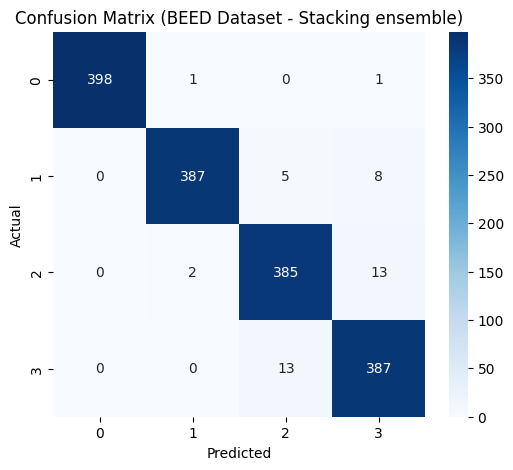

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (BEED Dataset - Stacking ensemble)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()